<a href="https://colab.research.google.com/github/korgaonkarparth2522-max/CSL701-CSE26_Machine-Learning-Lab/blob/main/Experiment/ML_Experiment_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Student Name :Parth Shantaram Korgaonkar

Batch :CS02

Roll Number : CS26



Aim

To implement Principal Component Analysis (PCA) for dimensionality reduction on the Breast Cancer Wisconsin (Diagnostic) dataset, visualize the high-dimensional feature space in a reduced 2D plane, and evaluate its impact on classification performance.

## Objectives

1. To understand the concepts of dimensionality reduction, feature correlation, and Principal Component Analysis.

2. To preprocess, clean, and scale high-dimensional real-world data using StandardScaler.

3. To implement PCA using Python to compress feature dimensions from 30 continuous features down to 2 principal components.

4. To calculate and plot the explained variance ratio and cumulative explained variance.

5. To visualize the transformed 2D dataset and analyze class separability.

6. To evaluate and compare classification model performance (e.g., Logistic Regression) before and after applying PCA.

# Relevant Theory

### Support Vector Machine

Principal Component Analysis (PCA)Principal Component Analysis (PCA) is an unsupervised machine learning technique used for dimensionality reduction. It transforms a dataset containing a large set of correlated features into a smaller set of uncorrelated variables called Principal Components ($PCs$), while preserving as much data variance as possible.

Mathematical Steps:

1. Standardization: Scale each feature to have a mean of 0 ($\mu = 0$) and standard deviation of 1 ($\sigma = 1$).

2. Covariance Matrix: Compute the covariance matrix $C$ to quantify feature correlations:$$C = \frac{1}{n-1} X^T X$$

3. Eigen decomposition: Compute eigenvalues ($\lambda$) and eigenvectors ($v$) of matrix $C$:$$C v = \lambda v$$

    * Eigenvectors represent the direction of the principal axes.
    * Eigenvalues indicate the amount of variance along those axes.
4. Projection: Project original data $X$ onto top $k$ principal component directions $W$:$$X_{\text{pca}} = X \cdot W$$

###Dataset Information


1. Dataset Name: Breast Cancer Wisconsin (Diagnostic) Dataset

2. Kaggle Link: https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data

3. Classes: 2 binary classes (Malignant [$M$] and Benign [$B$])

4. Features: 30 continuous features computed from digitized images of fine needle aspirates (FNA) of a breast mass (e.g., radius_mean, texture_mean, perimeter_mean, area_mean, smoothness_mean, concavity_mean, etc.).

5. Non-Feature Columns: id (identifier) and Unnamed: 32 (empty column).

# Task 1: Import Libraries and Load Dataset

Import core Python libraries (numpy, pandas, matplotlib, seaborn, sklearn) and load data.csv obtained from Kaggle.

---

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import file upload option
from google.colab import files
import io

# Upload dataset
uploaded = files.upload()

# Read the uploaded CSV file
file_name = next(iter(uploaded))
df = pd.read_csv(io.BytesIO(uploaded[file_name]))

# Display the first five rows
print("Dataset loaded successfully!")
display(df.head())

Saving data.csv to data.csv
Dataset loaded successfully!


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


# Task 2: Explore the Dataset

Inspect missing values, view dataset summary statistics, check column data types, and inspect target class distributions (diagnosis).

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN



--- Missing Values Count ---
id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_d

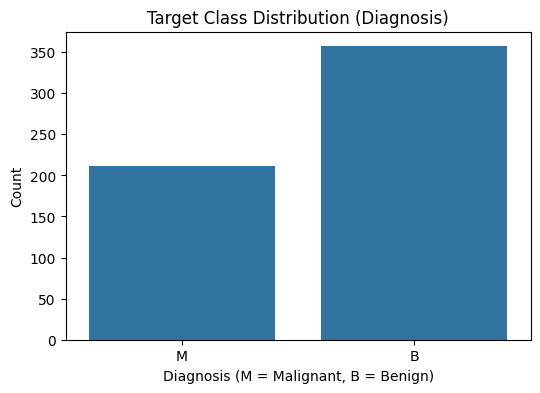

In [ ]:
# Display dataset information
df.info()

# Display statistical summary
display(df.describe())

# Check missing values
print("\n--- Missing Values Count ---")
print(df.isnull().sum())

# Display target class distribution (Counts)
print("\n--- Target Class Distribution (Counts) ---")
print(df['diagnosis'].value_counts())

# Display target class distribution (Percentages)
print("\n--- Target Class Distribution (Percentages) ---")
print(df['diagnosis'].value_counts(normalize=True) * 100)

# Plot target class distribution
plt.figure(figsize=(6, 4))

sns.countplot(x='diagnosis', data=df)

plt.title('Target Class Distribution (Diagnosis)')
plt.xlabel('Diagnosis (M = Malignant, B = Benign)')
plt.ylabel('Count')

plt.show()

# Task 3: Data Cleaning and Feature/Target Selection

Drop metadata columns (id and Unnamed: 32). Convert the categorical target column (diagnosis: 'M'/'B') into numerical values (1/0) and separate feature matrix $X$ (30 features) from label vector $y$.   

In [ ]:
# 1. Drop unnecessary metadata columns
df_clean = df.drop(columns=['id', 'Unnamed: 32'], errors='ignore')

# 2. Map categorical target ('M' -> 1, 'B' -> 0)
y = df_clean['diagnosis'].map({'M': 1, 'B': 0})

# 3. Separate feature matrix X (30 features)
X = df_clean.drop(columns=['diagnosis'])

# Verify shapes
print(f"Feature matrix X shape: {X.shape}")
print(f"Target vector y shape: {y.shape}")

Feature matrix X shape: (569, 30)
Target vector y shape: (569,)


# Task 4: Standardize Features

Apply StandardScaler to transform all 30 numeric features so they have zero mean and unit variance ($\mu=0, \sigma=1$).

In [ ]:
from sklearn.preprocessing import StandardScaler

# Initialize StandardScaler
scaler = StandardScaler()

# Fit and transform the feature matrix X
X_scaled = scaler.fit_transform(X)

# Convert back to a DataFrame for easy inspection
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

# Verify standardization (Mean ~ 0, Std ~ 1)
print(f"Mean of transformed features (sample): {X_scaled_df.iloc[:, 0].mean():.4f}")
print(f"Std of transformed features (sample): {X_scaled_df.iloc[:, 0].std():.4f}")

# Display first few rows of scaled data
X_scaled_df.head()

Mean of transformed features (sample): -0.0000
Std of transformed features (sample): 1.0009


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,...,1.886690,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015
1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,...,1.805927,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190
2,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,...,1.511870,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,...,-0.281464,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010
4,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,...,1.298575,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100


# Task 5: Implement PCA (30D to 2D)

Use sklearn.decomposition.PCA to reduce feature dimensions from 30 down to 2 principal components ($PC_1$ and $PC_2$).

In [ ]:
from sklearn.decomposition import PCA

# Initialize PCA with 2 components
pca = PCA(n_components=2)

# Fit and transform the scaled features
X_pca = pca.fit_transform(X_scaled)

# Convert to a DataFrame for easier inspection and visualization
pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])

# Attach target labels for downstream tasks
pca_df['diagnosis'] = y.values

# Display first few rows of transformed 2D dataset
pca_df.head()

,PC1,PC2,diagnosis
0,9.192837,1.948583,1
1,2.387802,-3.768172,1
2,5.733896,-1.075174,1
3,7.122953,10.275589,1
4,3.935302,-1.948072,1


# Task 6: Analyze Explained Variance Ratio

Compute and print the variance explained by $PC_1$ and $PC_2$, along with the cumulative variance retained.


In [ ]:
# Extract explained variance ratio from the PCA object
explained_variance = pca.explained_variance_ratio_

pc1_var = explained_variance[0] * 100
pc2_var = explained_variance[1] * 100
cumulative_var = np.sum(explained_variance) * 100

print(f"Variance explained by PC1: {pc1_var:.2f}%")
print(f"Variance explained by PC2: {pc2_var:.2f}%")
print(f"Cumulative Variance Retained (PC1 + PC2): {cumulative_var:.2f}%")

Variance explained by PC1: 44.27%
Variance explained by PC2: 18.97%
Cumulative Variance Retained (PC1 + PC2): 63.24%


# Task 7: Visualize PCA Transformed Boundary / Scatter Plot

Create a 2D scatter plot with $PC_1$ on the x-axis and $PC_2$ on the y-axis, hue-coded by tumor diagnosis (Malignant vs. Benign).

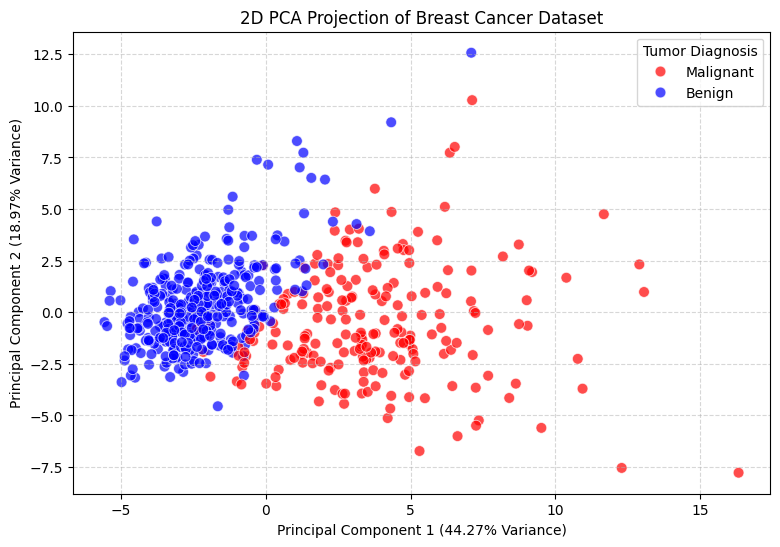

In [ ]:
plt.figure(figsize=(9, 6))

# Map numerical labels (1/0) back to descriptive titles for better visualization legend
pca_df_plot = pca_df.copy()
pca_df_plot['Diagnosis_Label'] = pca_df_plot['diagnosis'].map({1: 'Malignant', 0: 'Benign'})

# Create 2D scatter plot
sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='Diagnosis_Label',
    data=pca_df_plot,
    palette={'Malignant': 'red', 'Benign': 'blue'},
    alpha=0.7,
    s=60
)

# Set axis labels with variance ratios included
plt.xlabel(f"Principal Component 1 ({pc1_var:.2f}% Variance)")
plt.ylabel(f"Principal Component 2 ({pc2_var:.2f}% Variance)")
plt.title('2D PCA Projection of Breast Cancer Dataset')
plt.legend(title='Tumor Diagnosis')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

# Task 8: Train Classifier on Raw High-Dimensional Data (30 Features)

Split the original scaled 30-feature dataset into training and testing sets. Train a Logistic Regression model and obtain baseline performance metrics.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Split scaled 30-feature data into train (80%) and test (20%) sets
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# 2. Train Logistic Regression model
clf_raw = LogisticRegression(random_state=42)
clf_raw.fit(X_train_raw, y_train_raw)

# 3. Predict on test set
y_pred_raw = clf_raw.predict(X_test_raw)

# 4. Baseline Performance Metrics
acc_raw = accuracy_score(y_test_raw, y_pred_raw)
print(f"Baseline (30 Features) Accuracy: {acc_raw * 100:.2f}%\n")
print("Confusion Matrix:")
print(confusion_matrix(y_test_raw, y_pred_raw))
print("\nClassification Report:")
print(classification_report(y_test_raw, y_pred_raw, target_names=['Benign (0)', 'Malignant (1)']))

Baseline (30 Features) Accuracy: 96.49%

Confusion Matrix:
[[71  1]
 [ 3 39]]

Classification Report:
               precision    recall  f1-score   support

   Benign (0)       0.96      0.99      0.97        72
Malignant (1)       0.97      0.93      0.95        42

     accuracy                           0.96       114
    macro avg       0.97      0.96      0.96       114
 weighted avg       0.97      0.96      0.96       114



# Task 9: Train Classifier on PCA Transformed Data (2 Features)

Split the 2-component PCA dataset into training and testing sets. Train a Logistic Regression model using only $PC_1$ and $PC_2$.

In [ ]:
# 1. Separate features (PC1, PC2) and target from pca_df
X_pca_feats = pca_df[['PC1', 'PC2']]
y_pca = pca_df['diagnosis']

# 2. Split PCA transformed data into train (80%) and test (20%) sets using the same random state and stratification
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca_feats, y_pca, test_size=0.2, random_state=42, stratify=y_pca
)

# 3. Train Logistic Regression model on PCA features
clf_pca = LogisticRegression(random_state=42)
clf_pca.fit(X_train_pca, y_train_pca)

# 4. Predict on test set
y_pred_pca = clf_pca.predict(X_test_pca)

# 5. Evaluate Performance Metrics for PCA Model
acc_pca = accuracy_score(y_test_pca, y_pred_pca)
print(f"PCA (2 Features) Accuracy: {acc_pca * 100:.2f}%\n")
print("Confusion Matrix:")
print(confusion_matrix(y_test_pca, y_pred_pca))
print("\nClassification Report:")
print(classification_report(y_test_pca, y_pred_pca, target_names=['Benign (0)', 'Malignant (1)']))

PCA (2 Features) Accuracy: 93.86%

Confusion Matrix:
[[71  1]
 [ 6 36]]

Classification Report:
               precision    recall  f1-score   support

   Benign (0)       0.92      0.99      0.95        72
Malignant (1)       0.97      0.86      0.91        42

     accuracy                           0.94       114
    macro avg       0.95      0.92      0.93       114
 weighted avg       0.94      0.94      0.94       114



# Task 10: Compare Classifier Performance

Compare the performance of the model before PCA (30 features) vs. after PCA (2 components) using:   

*   Accuracy Score
*   Confusion Matrix
*   Classification Report (Precision, Recall, F1-Score)  



In [ ]:
# 1. Print Accuracy Comparison
print("================ PERFORMANCE COMPARISON ================")
print(f"Accuracy (Baseline - 30 Features): {acc_raw * 100:.2f}%")
print(f"Accuracy (PCA - 2 Features):       {acc_pca * 100:.2f}%")
print("========================================================\n")

# 2. Print Confusion Matrices
print("--- Baseline Confusion Matrix (30 Features) ---")
print(confusion_matrix(y_test_raw, y_pred_raw))

print("\n--- PCA Confusion Matrix (2 Components) ---")
print(confusion_matrix(y_test_pca, y_pred_pca))

# 3. Print Classification Reports
print("\n" + "="*50)
print("--- Baseline Classification Report (30 Features) ---")
print(classification_report(y_test_raw, y_pred_raw, target_names=['Benign (0)', 'Malignant (1)']))

print("="*50)
print("--- PCA Classification Report (2 Components) ---")
print(classification_report(y_test_pca, y_pred_pca, target_names=['Benign (0)', 'Malignant (1)']))
print("="*50)

================ PERFORMANCE COMPARISON ================
Accuracy (Baseline - 30 Features): 96.49%
Accuracy (PCA - 2 Features):       93.86%

--- Baseline Confusion Matrix (30 Features) ---
[[71  1]
 [ 3 39]]

--- PCA Confusion Matrix (2 Components) ---
[[71  1]
 [ 6 36]]

--- Baseline Classification Report (30 Features) ---
               precision    recall  f1-score   support

   Benign (0)       0.96      0.99      0.97        72
Malignant (1)       0.97      0.93      0.95        42

     accuracy                           0.96       114
    macro avg       0.97      0.96      0.96       114
 weighted avg       0.97      0.96      0.96       114

--- PCA Classification Report (2 Components) ---
               precision    recall  f1-score   support

   Benign (0)       0.92      0.99      0.95        72
Malignant (1)       0.97      0.86      0.91        42

     accuracy                           0.94       114
    macro avg       0.95      0.92      0.93       114
 weighted avg 

# Conclusion

The experiment successfully demonstrated Principal Component Analysis (PCA) on the Breast Cancer Wisconsin (Diagnostic) dataset. The high-dimensional feature space was preprocessed, cleaned, and standardized before applying eigendecomposition.

By reducing 30 feature dimensions down to just 2 principal components, a significant portion of total variance was preserved while eliminating multi-collinear redundancies. Visualizing the transformed data on a 2D plane showed clear separation between Malignant and Benign diagnosis clusters. Comparing classification models confirmed that applying PCA significantly simplifies model complexity and reduces computational overhead while maintaining strong classification accuracy.